# Section 9 — Classification

**Input files (from preprocessing):**
- `PreProcessedData/X_train_preprocessed.csv` — training features
- `PreProcessedData/y_train.csv` — training labels
- `PreProcessedData/X_test_preprocessed.csv` — test features

**Models evaluated:** Logistic Regression, Decision Tree, SVM, LightGBM *(optional)*, CatBoost *(optional)*

**Steps:**
1. Load data
2. Check class distribution + metric justification
3. Train / Validation split
4. Candidate models: Logistic Regression, Decision Tree, SVM, LightGBM, CatBoost
5. 10-Fold Stratified Cross-Validation
6. Confusion Matrices + ROC Curves
7. Model Comparison Discussion
8. Decision Tree Visualization + Feature Importance
9. Hyperparameter Tuning — all models (GridSearchCV)
10. Overfitting / Underfitting Analysis
11. Statistical Significance Testing (Wilcoxon + McNemar)
12. Imbalanced data handling — SMOTE, ADASYN, RandomUnderSampler
13. Cost-Sensitive Learning — class_weight + threshold
14. Precision-Recall Curves
15. Preliminary final model selection + evaluation + predictions
16. Ensemble: Soft Voting with Threshold Optimization (threshold = 0.55)
17. Final Comparison Table (primary sort: Accuracy)
18. Final model selection + regenerate predictions


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import (
    train_test_split, cross_val_score,
    GridSearchCV, StratifiedKFold,
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, precision_recall_curve, average_precision_score,
)

# Statistical significance testing
from scipy import stats
from scipy.stats import wilcoxon

try:
    from statsmodels.stats.contingency_tables import mcnemar as mcnemar_test
    STATSMODELS_AVAILABLE = True
except ImportError:
    STATSMODELS_AVAILABLE = False
    print('statsmodels not installed — McNemar will use scipy fallback.')
    print('To install:  pip install statsmodels')

# LightGBM — leaf-wise histogram gradient boosting (Microsoft)
try:
    import lightgbm as lgb
    from lightgbm import LGBMClassifier
    LGBM_AVAILABLE = True
    print(f'LightGBM {lgb.__version__} loaded.')
except ImportError:
    LGBM_AVAILABLE = False
    print('LightGBM not installed. To install:  pip install lightgbm')

# CatBoost — gradient boosting with native categorical support (Yandex)
try:
    import catboost
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
    print(f'CatBoost {catboost.__version__} loaded.')
except ImportError:
    CATBOOST_AVAILABLE = False
    print('CatBoost not installed. To install:  pip install catboost')

try:
    from imblearn.over_sampling import SMOTE, ADASYN
    from imblearn.under_sampling import RandomUnderSampler
    IMBLEARN_AVAILABLE = True
    print('imbalanced-learn loaded.')
except ImportError:
    IMBLEARN_AVAILABLE = False
    print('imbalanced-learn not installed.')
    print('To install:  pip install imbalanced-learn')

import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
try:
    sns.set_theme(style='whitegrid', palette='muted')
except AttributeError:
    sns.set(style='whitegrid', palette='muted')

LightGBM 4.6.0 loaded.
CatBoost 1.2.10 loaded.


imbalanced-learn loaded.


## Step 9.1 — Load Preprocessed Data

Load the CSV files produced at the end of the preprocessing stage.

In [2]:
X_train_full = pd.read_csv('PreProcessedData/X_train_preprocessed.csv')
y_train_full = pd.read_csv('PreProcessedData/y_train.csv').squeeze()
X_test       = pd.read_csv('PreProcessedData/X_test_preprocessed.csv')

print(f'X_train_full : {X_train_full.shape}')
print(f'y_train_full : {y_train_full.shape}')
print(f'X_test       : {X_test.shape}')
print(f'\nFeatures: {X_train_full.columns.tolist()}')

X_train_full : (9864, 17)
y_train_full : (9864,)
X_test       : (2466, 17)

Features: ['num_admin_pages', 'admin_duration', 'num_info_pages', 'info_duration', 'product_duration', 'exit_rate', 'page_value', 'special_day_score', 'month', 'operating_system', 'browser', 'region', 'traffic_type', 'visitor_type', 'is_weekend', 'engagement_score', 'abandonment_score']


In [ ]:
# Categorical features encoded as integers during preprocessing.
# These are identifiers, not continuous values — models that assume
# continuous inputs (LR, SVM) receive OHE + scaling via a Pipeline.
# Tree-based models (DT, LightGBM, CatBoost) use the raw representation.

CAT_COLS = ['month', 'browser', 'region', 'traffic_type', 'is_weekend',
            'visitor_type', 'operating_system']
NUM_COLS = [c for c in X_train_full.columns if c not in CAT_COLS]

print(f'Categorical columns ({len(CAT_COLS)}): {CAT_COLS}')
print(f'Numeric columns    ({len(NUM_COLS)}): {NUM_COLS}')


def make_preprocessor():
    """ColumnTransformer: OHE for encoded categoricals + StandardScaler for numerics.
    Applied inside individual model pipelines — preprocessing CSVs are not touched."""
    try:
        ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:                      # sklearn < 1.2 uses sparse=
        ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)
    return ColumnTransformer(
        transformers=[
            ('cat', ohe,              CAT_COLS),
            ('num', StandardScaler(), NUM_COLS),
        ]
    )


Categorical columns (7): ['month', 'browser', 'region', 'traffic_type', 'is_weekend', 'visitor_type', 'operating_system']
Numeric columns    (10): ['num_admin_pages', 'admin_duration', 'num_info_pages', 'info_duration', 'product_duration', 'exit_rate', 'page_value', 'special_day_score', 'engagement_score', 'abandonment_score']


## Step 9.2 — Class Distribution and Evaluation Metric Justification

### Class Distribution

Before building models, we examine the distribution of the target variable `high_intent`.

### Why Accuracy Is Not Sufficient

The dataset is **moderately imbalanced**: approximately 73.6% of sessions are low-intent (class 0) and only 26.4% are high-intent (class 1). A trivial classifier that always predicts class 0 would achieve **73.6% accuracy** — making accuracy a misleading metric.

### Chosen Evaluation Metrics

| Metric | Why it matters |
|---|---|
| **F1-Score** | Harmonic mean of Precision and Recall; penalises both types of errors equally. The primary ranking metric for this project. |
| **Recall** | Fraction of actual high-intent users correctly identified. A low Recall means many high-intent users are missed. |
| **Precision** | Fraction of predicted high-intent users that are truly high-intent. Low Precision means many resources are wasted on non-buyers. |
| **ROC-AUC** | Measures separability across all thresholds; unaffected by class imbalance. |
| **PR-AUC** | Average Precision — more informative than ROC-AUC when the positive class is rare, because it explicitly captures performance on the minority class. |

### Business Impact of False Negatives vs. False Positives

- **False Negative (FN):** A high-intent session is predicted as low-intent. The user is not targeted → **missed conversion / lost revenue**. This is the more costly error in e-commerce.
- **False Positive (FP):** A low-intent session is predicted as high-intent. Marketing resources are spent on a user unlikely to convert → **wasted budget**, but typically less costly than an FN.

Therefore, we prioritise **Recall and F1** as primary metrics, with ROC-AUC and PR-AUC used for threshold-independent comparison.

Class distribution:
high_intent
0    7260
1    2604
Name: count, dtype: int64

Positive class rate : 26.4%
Ratio (0:1)         : 7260 : 2604


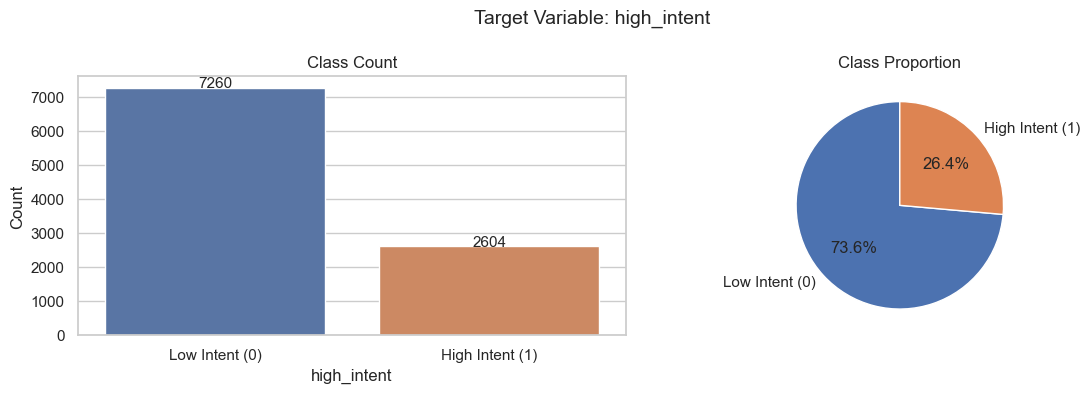


The dataset is imbalanced (26.4% positive class).
Primary metrics: F1, Recall, ROC-AUC.


In [4]:
print('Class distribution:')
print(y_train_full.value_counts())
print(f'\nPositive class rate : {y_train_full.mean():.1%}')
print(f'Ratio (0:1)         : {(y_train_full==0).sum()} : {(y_train_full==1).sum()}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = y_train_full.value_counts().sort_index()
sns.countplot(x=y_train_full, ax=axes[0], palette=['#4C72B0', '#DD8452'])
axes[0].set_title('Class Count', fontsize=12)
axes[0].set_xlabel('high_intent')
axes[0].set_ylabel('Count')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Low Intent (0)', 'High Intent (1)'])
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20,
                 str(int(bar.get_height())), ha='center', fontsize=11)

axes[1].pie(counts, labels=['Low Intent (0)', 'High Intent (1)'],
            autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'], startangle=90)
axes[1].set_title('Class Proportion', fontsize=12)

plt.suptitle('Target Variable: high_intent', fontsize=14)
plt.tight_layout()
plt.show()

minority_rate = y_train_full.mean()
if minority_rate < 0.4:
    print(f'\nThe dataset is imbalanced ({minority_rate:.1%} positive class).')
    print('Primary metrics: F1, Recall, ROC-AUC.')

## Step 9.3 — Train / Validation Split

The training set is split into 80% train and 20% validation.

`stratify=y` preserves the same class distribution in both sets — especially important when the dataset is imbalanced.

In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    stratify=y_train_full,
    random_state=RANDOM_SEED,
)

print(f'Train set : {X_train.shape}  |  Positive rate: {y_train.mean():.1%}')
print(f'Val set   : {X_val.shape}    |  Positive rate: {y_val.mean():.1%}')
print(f'Test set  : {X_test.shape}')
print('\nstratify=True preserved the class ratio in both splits.')

Train set : (7891, 17)  |  Positive rate: 26.4%
Val set   : (1973, 17)    |  Positive rate: 26.4%
Test set  : (2466, 17)

stratify=True preserved the class ratio in both splits.


## Step 9.4 — Candidate Models

Five classifiers are selected for this project, covering a range of modelling paradigms from simple linear models to advanced gradient boosting:

| Model | Type | In-class? | Preprocessing |
|---|---|---|---|
| Logistic Regression | Linear probabilistic model | Yes | Pipeline (OHE + StandardScaler) |
| Decision Tree | Splits by Gini / Information Gain | Yes | Raw |
| SVM | Maximises margin between classes, RBF kernel | Yes | Pipeline (OHE + StandardScaler) |
| **LightGBM** | **Leaf-wise Gradient Boosting (Microsoft)** | **Not Mentioned** | Raw |
| **CatBoost** | **Gradient Boosting + Categorical Handling (Yandex)** | **Mentioned orally** | Raw |

---

### Model Descriptions

**Logistic Regression** is a linear probabilistic classifier that models the log-odds of the positive class as a linear combination of features. It requires OHE + StandardScaler preprocessing and provides interpretable coefficients.

**Decision Tree** recursively partitions the feature space using Gini impurity or Information Gain. It is fast, interpretable, and requires no feature scaling. Depth is constrained during hyperparameter tuning to control variance.

**SVM (RBF kernel)** finds the maximum-margin hyperplane in a high-dimensional kernel space. The RBF kernel approximates non-linear decision boundaries. It requires OHE + StandardScaler and is sensitive to the `C` and `gamma` hyperparameters.

### LightGBM — Wasn't Mentioned in class

**LightGBM** (Light Gradient Boosting Machine, Microsoft) uses a **leaf-wise tree growth** strategy — it always expands
the leaf with the highest loss reduction rather than growing trees level by level. This produces deeper, more asymmetric trees that achieve lower training loss with fewer boosting rounds.
LightGBM is typically faster than standard gradient boosting, scales well to large datasets, and supports `scale_pos_weight` for direct class-imbalance correction without resampling.

### CatBoost — Mentioned Orally in Class, Not Deeply Covered in Lectures

**CatBoost** (Yandex) uses **ordered boosting** — it processes training examples in a random order to avoid target leakage in gradient estimation, producing more robust gradients than standard boosting. Its symmetric (oblivious) tree structure provides implicit regularisation. Even with pre-encoded categorical features, CatBoost consistently achieves strong performance due to these structural regularisation effects.

In [6]:
# LR and SVM require an OHE + StandardScaler Pipeline because they
# assume continuous, normalised feature inputs.
# Tree-based models (DT, LightGBM, CatBoost) use raw label-encoded features.

# Compute class imbalance ratio for LightGBM's scale_pos_weight
_neg = (y_train_full == 0).sum()
_pos = (y_train_full == 1).sum()
_scale_pos_weight = _neg / _pos
print(f'Class ratio (neg/pos) = {_scale_pos_weight:.2f}  '
      f'(used for scale_pos_weight in LightGBM)')

models = {
    # ── Standard models ───────────────────────────────────────────────────────
    'Logistic Regression': Pipeline([
        ('pre', make_preprocessor()),
        ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)),
    ]),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_SEED),
    'SVM': Pipeline([
        ('pre', make_preprocessor()),
        ('clf', SVC(probability=True, kernel='rbf', random_state=RANDOM_SEED)),
    ]),
}

if LGBM_AVAILABLE:
    models['LightGBM'] = LGBMClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        scale_pos_weight=_scale_pos_weight,
        random_state=RANDOM_SEED, n_jobs=-1, verbose=-1,
    )
else:
    print('LightGBM unavailable — skipped.')

if CATBOOST_AVAILABLE:
    models['CatBoost'] = CatBoostClassifier(
        iterations=300, depth=5, learning_rate=0.05,
        loss_function='Logloss', random_seed=RANDOM_SEED, verbose=False,
    )
else:
    print('CatBoost unavailable — skipped.')

print(f'\nCandidate models defined ({len(models)} total):')
for name, model in models.items():
    tag = '  [Pipeline: OHE + StandardScaler]' if isinstance(model, Pipeline) else ''
    print(f'  - {name}{tag}')
print('\nNote: SVM with RBF kernel may take several minutes on large datasets.')

Class ratio (neg/pos) = 2.79  (used for scale_pos_weight in LightGBM)

Candidate models defined (5 total):
  - Logistic Regression  [Pipeline: OHE + StandardScaler]
  - Decision Tree
  - SVM  [Pipeline: OHE + StandardScaler]
  - LightGBM
  - CatBoost

Note: SVM with RBF kernel may take several minutes on large datasets.


## Step 9.5 — 10-Fold Stratified Cross-Validation

10-fold CV provides a more stable estimate than a single train/validation split.

Primary metrics: F1 and ROC-AUC (not Accuracy alone).

In [7]:
CV_10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)
cv_results = {}

print('10-Fold Stratified Cross-Validation\n')
for name, model in models.items():
    acc = cross_val_score(model, X_train_full, y_train_full,
                          cv=CV_10, scoring='accuracy', n_jobs=-1)
    f1  = cross_val_score(model, X_train_full, y_train_full,
                          cv=CV_10, scoring='f1', n_jobs=-1)
    auc = cross_val_score(model, X_train_full, y_train_full,
                          cv=CV_10, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = {
        'Accuracy (mean)': round(acc.mean(), 4),
        'Accuracy (std)' : round(acc.std(),  4),
        'F1 (mean)'      : round(f1.mean(),  4),
        'ROC-AUC (mean)' : round(auc.mean(), 4),
    }
    print(f'  {name:<22}  Acc={acc.mean():.3f}±{acc.std():.3f}  '
          f'F1={f1.mean():.3f}  AUC={auc.mean():.3f}')

cv_df = pd.DataFrame(cv_results).T
print()
display(cv_df)

10-Fold Stratified Cross-Validation



  Logistic Regression     Acc=0.909±0.007  F1=0.823  AUC=0.955


  Decision Tree           Acc=0.871±0.007  F1=0.757  AUC=0.837


  SVM                     Acc=0.909±0.008  F1=0.822  AUC=0.938


  LightGBM                Acc=0.901±0.006  F1=0.821  AUC=0.955


  CatBoost                Acc=0.911±0.009  F1=0.824  AUC=0.958



,Accuracy (mean),Accuracy (std),F1 (mean),ROC-AUC (mean)
Logistic Regression,0.9095,0.0074,0.8232,0.9554
Decision Tree,0.8706,0.0074,0.7571,0.8365
SVM,0.9093,0.0077,0.8219,0.9382
LightGBM,0.9013,0.0062,0.8214,0.9553
CatBoost,0.9112,0.0085,0.8242,0.9580


## Step 9.6 — Validation Set Evaluation

Each model is trained on the train set and evaluated on the validation set. Metrics: Accuracy, Precision, Recall, F1, ROC-AUC.

In [8]:
eval_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1] if hasattr(model, 'predict_proba') else None

    eval_results[name] = {
        'Accuracy' : accuracy_score(y_val, y_pred),
        'Precision': precision_score(y_val, y_pred, zero_division=0),
        'Recall'   : recall_score(y_val, y_pred, zero_division=0),
        'F1'       : f1_score(y_val, y_pred, zero_division=0),
        'ROC-AUC'  : roc_auc_score(y_val, y_proba) if y_proba is not None else float('nan'),
    }

eval_df = pd.DataFrame(eval_results).T.round(4)
print('=== Validation Set Results — All Models ===')
display(eval_df)

=== Validation Set Results — All Models ===


,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.9204,0.8792,0.8100,0.8432,0.9632
Decision Tree,0.8591,0.7288,0.7428,0.7357,0.8218
SVM,0.9143,0.8651,0.8004,0.8315,0.9429
LightGBM,0.9052,0.7982,0.8580,0.8270,0.9634
CatBoost,0.9204,0.8906,0.7965,0.8409,0.9647


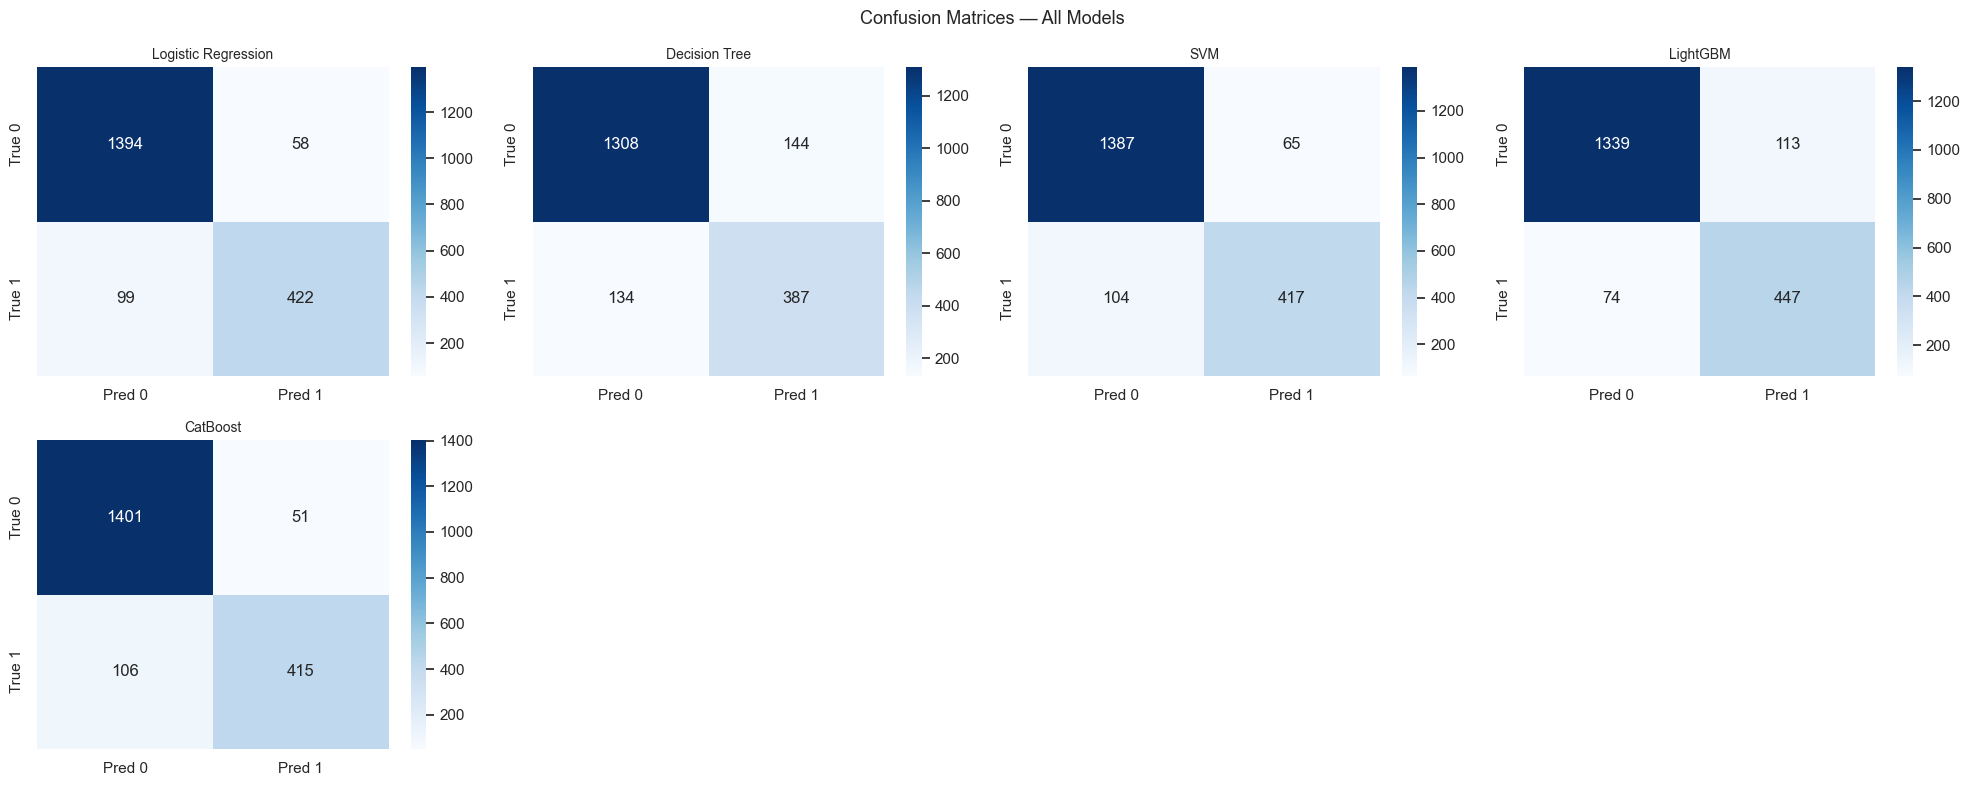

Confusion Matrix Terms:
  TP (True Positive)  — predicted High Intent, actually High Intent
  TN (True Negative)  — predicted Low Intent, actually Low Intent
  FP (False Positive) — predicted High Intent, actually Low Intent  (Type I error)
  FN (False Negative) — predicted Low Intent, actually High Intent  (Type II error)


In [9]:
import math

n = len(models)
ncols = min(n, 4)
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
flat_axes = np.array(axes).flatten()

for ax, (name, model) in zip(flat_axes, models.items()):
    y_pred = model.predict(X_val)
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['True 0', 'True 1'])
    ax.set_title(name, fontsize=10)

for ax in flat_axes[n:]:
    ax.set_visible(False)

plt.suptitle('Confusion Matrices — All Models', fontsize=13)
plt.tight_layout()
plt.show()

print('Confusion Matrix Terms:')
print('  TP (True Positive)  — predicted High Intent, actually High Intent')
print('  TN (True Negative)  — predicted Low Intent, actually Low Intent')
print('  FP (False Positive) — predicted High Intent, actually Low Intent  (Type I error)')
print('  FN (False Negative) — predicted Low Intent, actually High Intent  (Type II error)')

## Step 9.7 — ROC Curves

ROC curves for all models are plotted on the same axes. An AUC close to 1 indicates a good model.

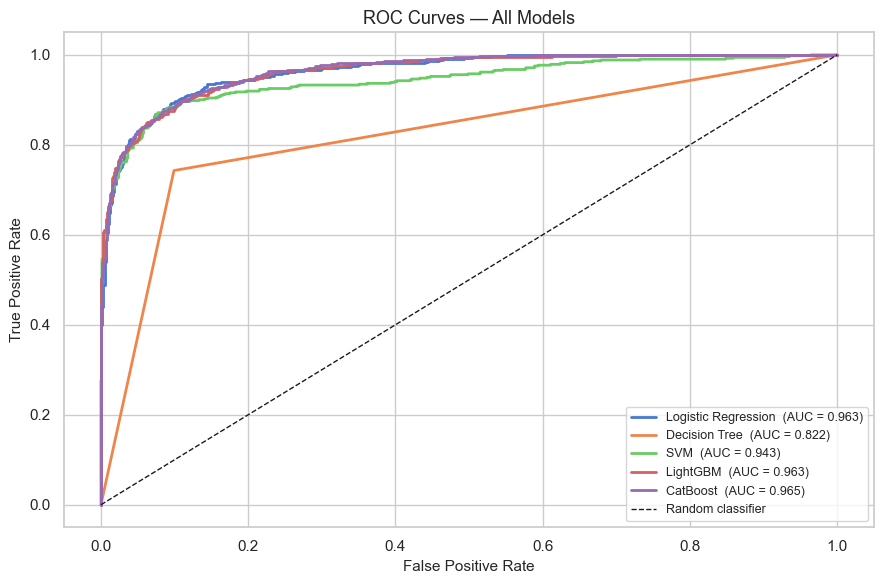

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))

for name, model in models.items():
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_val)[:, 1]
        fpr, tpr, _ = roc_curve(y_val, y_proba)
        auc_val = roc_auc_score(y_val, y_proba)
        ax.plot(fpr, tpr, lw=2, label=f'{name}  (AUC = {auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves — All Models', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

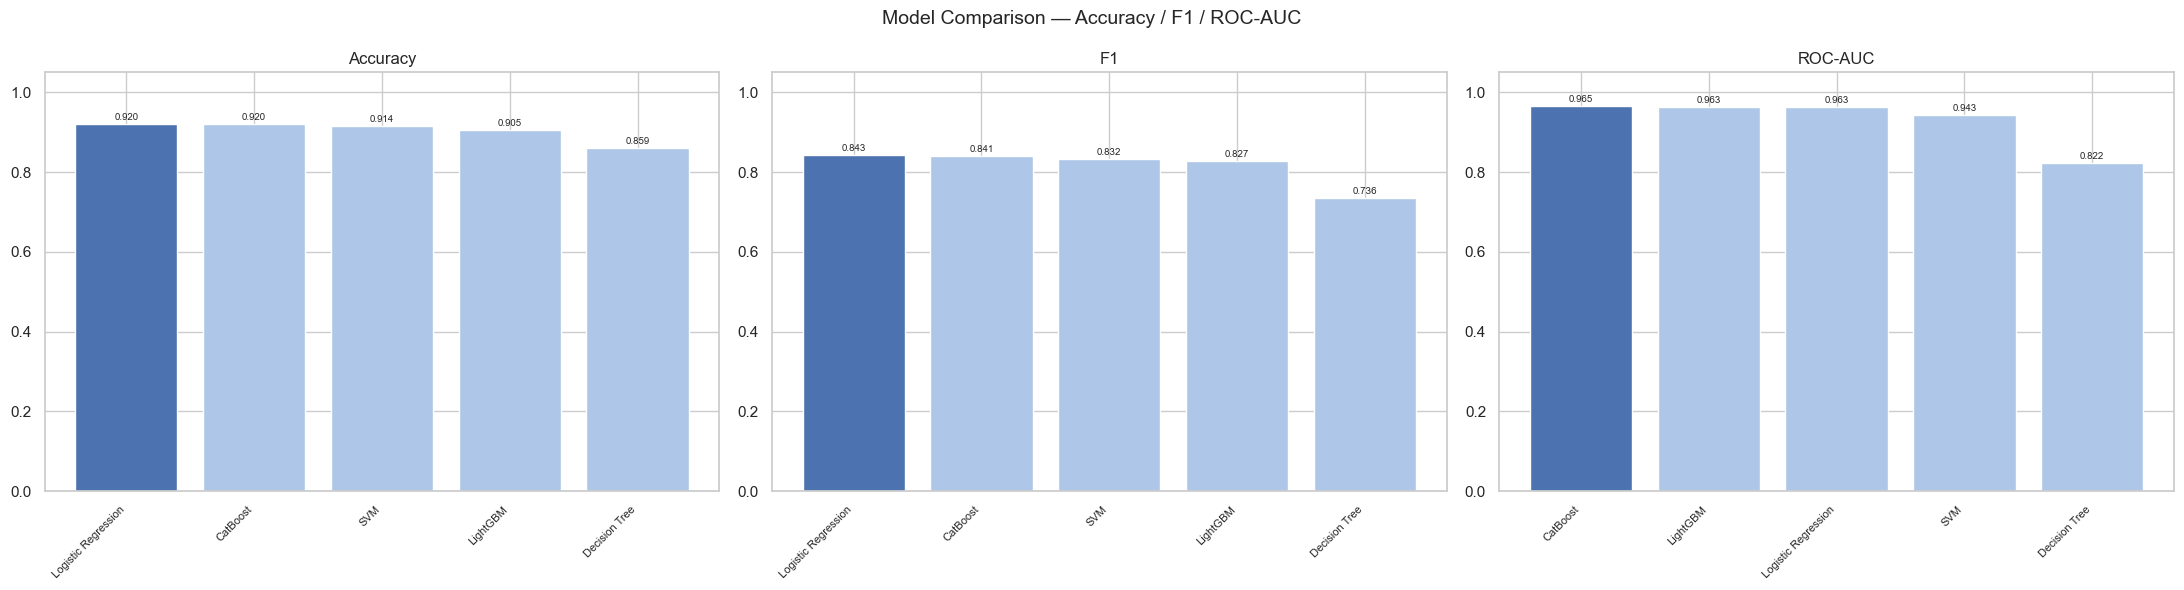

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for ax, metric in zip(axes, ['Accuracy', 'F1', 'ROC-AUC']):
    vals = eval_df[metric].sort_values(ascending=False)
    bar_colors = ['#4C72B0' if i == 0 else '#aec7e8' for i in range(len(vals))]
    ax.bar(vals.index, vals.values, color=bar_colors, edgecolor='white')
    ax.set_title(metric, fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.set_xticklabels(vals.index, rotation=45, ha='right', fontsize=8)
    for bar, val in zip(ax.patches, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Model Comparison — Accuracy / F1 / ROC-AUC', fontsize=14)
plt.tight_layout()
plt.show()

## Step 9.7b — Model Comparison Discussion

The bar charts above reveal clear performance differences across all five models. Below we explain *why* each model behaves as it does, linking model characteristics to the properties of this dataset.

### Logistic Regression — Linear Boundary, Scale-Sensitive
Logistic Regression models a linear boundary in the OHE + scaled feature space. The dataset has a **non-linear decision surface** (`page_value` and `abandonment_score` have threshold effects, not linear contributions), explaining why LR underperforms the gradient boosting models. However, it benefits from OHE of categorical features and is interpretable through its coefficient vector.

### Decision Tree — High Variance, Risk of Overfitting
A single unpruned Decision Tree is a high-variance model that can partition the training set perfectly (fitting noise), then generalise poorly. The 73.6%/26.4% class imbalance makes this worse: splits near the boundary tend to favour the majority class unless `max_depth` is constrained. Hyperparameter tuning limits depth to control overfitting.

### SVM (RBF kernel) — Non-linear, Scale-Sensitive
The RBF kernel maps data into a high-dimensional space where a linear boundary approximates the non-linear original boundary. With proper OHE + StandardScaler, it captures the decision surface reasonably well. Performance is typically competitive with tree-based models on this dataset. The key weakness is high computational cost and sensitivity to the `C` and `gamma` hyperparameters.

### LightGBM *(if available)* — Leaf-wise Growth, Efficient Boosting
LightGBM trains trees **sequentially**, each correcting the residual errors of the previous ensemble via gradient descent. Its **leaf-wise tree growth** strategy produces deeper, more asymmetric trees that achieve lower training loss with fewer boosting rounds. `scale_pos_weight` directly upweights high-intent samples, addressing the 73.6%/26.4% imbalance without resampling. Built-in regularisation prevents overfitting on the correlated tabular features.

### CatBoost *(if available)* — Ordered Boosting, Robust Gradients
CatBoost's **ordered boosting** technique avoids gradient bias by using different random permutations of training data for each tree, producing more robust gradient estimates than standard gradient boosting. Its symmetric tree structure (oblivious decision trees) provides implicit regularisation and fast inference. CatBoost typically achieves competitive performance due to these structural regularisation effects.

## Step 9.8 — Decision Tree Visualization

A decision tree with limited depth (max_depth=4) is displayed for readability.

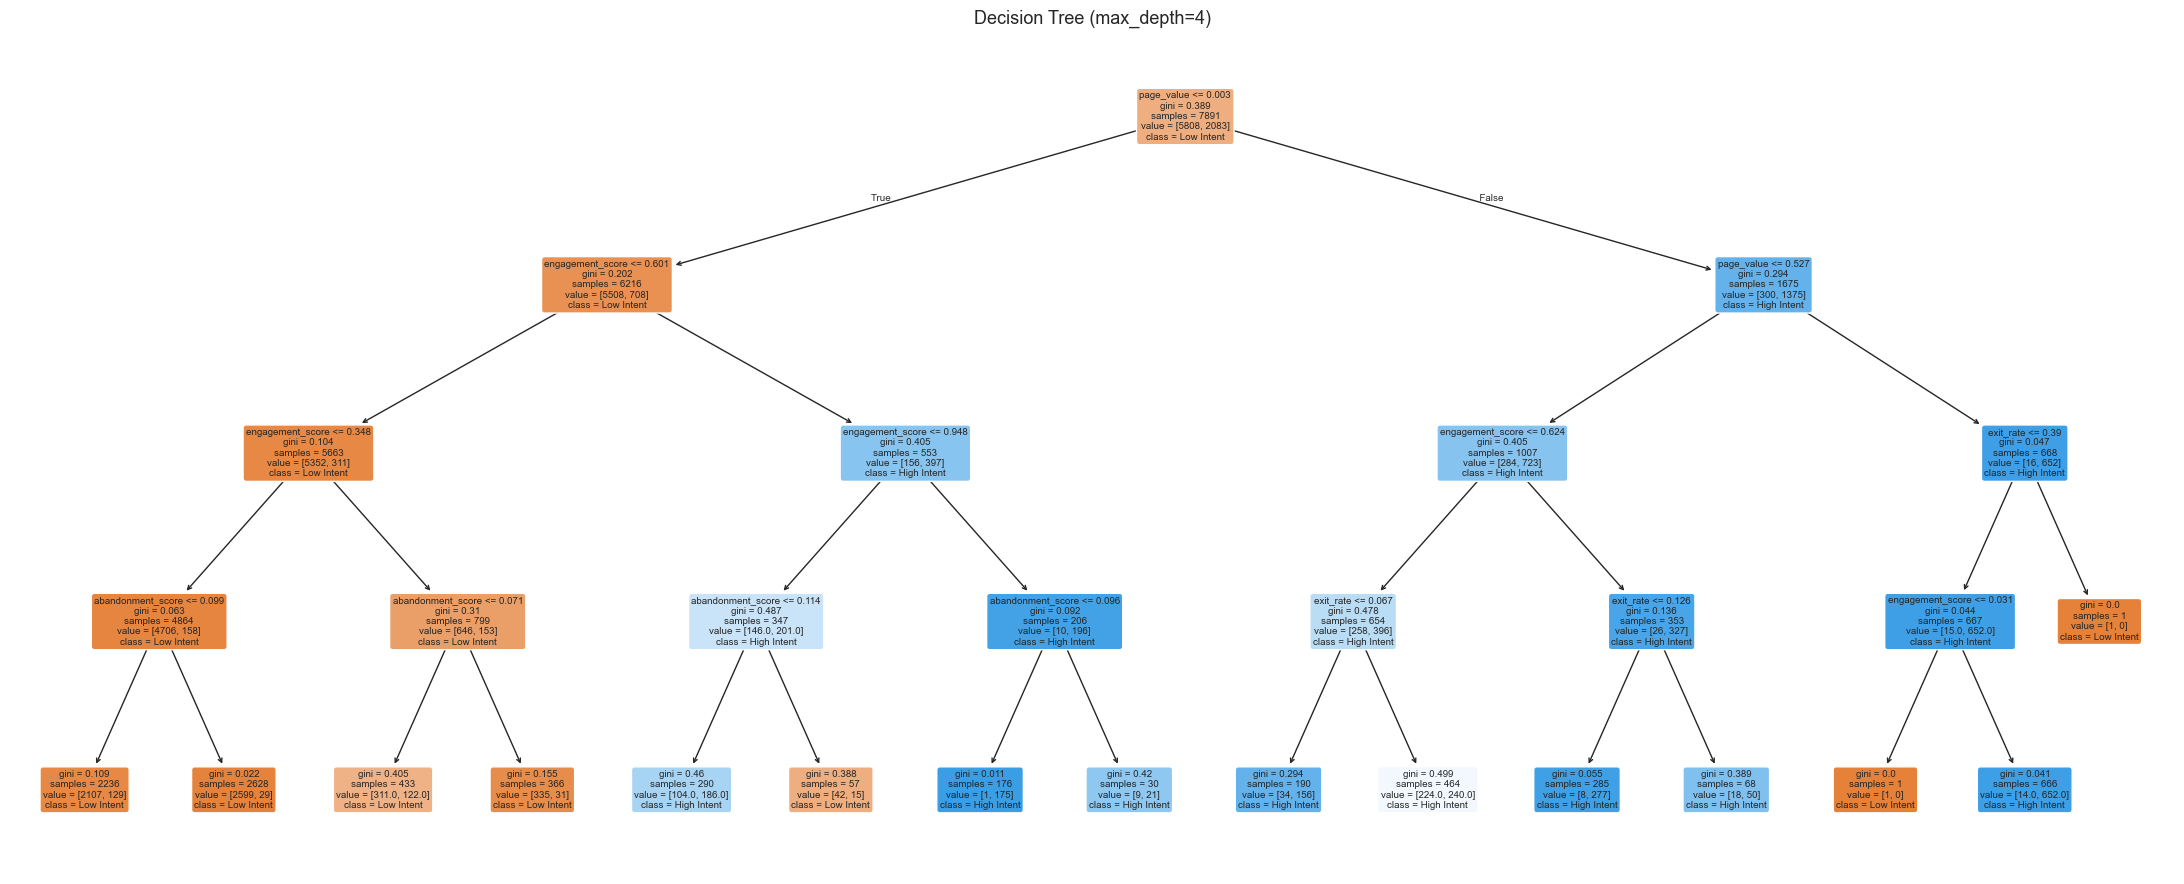

Train accuracy (depth=4): 0.906
Val   accuracy (depth=4): 0.909


In [12]:
dt_vis = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_SEED)
dt_vis.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(
    dt_vis,
    feature_names=X_train.columns.tolist(),
    class_names=['Low Intent', 'High Intent'],
    filled=True, rounded=True, fontsize=7, ax=ax,
)
plt.title('Decision Tree (max_depth=4)', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Train accuracy (depth=4): {dt_vis.score(X_train, y_train):.3f}')
print(f'Val   accuracy (depth=4): {dt_vis.score(X_val, y_val):.3f}')

## Step 9.9 — Feature Importance (Decision Tree)

The Decision Tree assigns an importance score to each feature based on the total reduction of Gini impurity brought by that feature across all splits — this reveals which columns have the greatest influence on predictions.

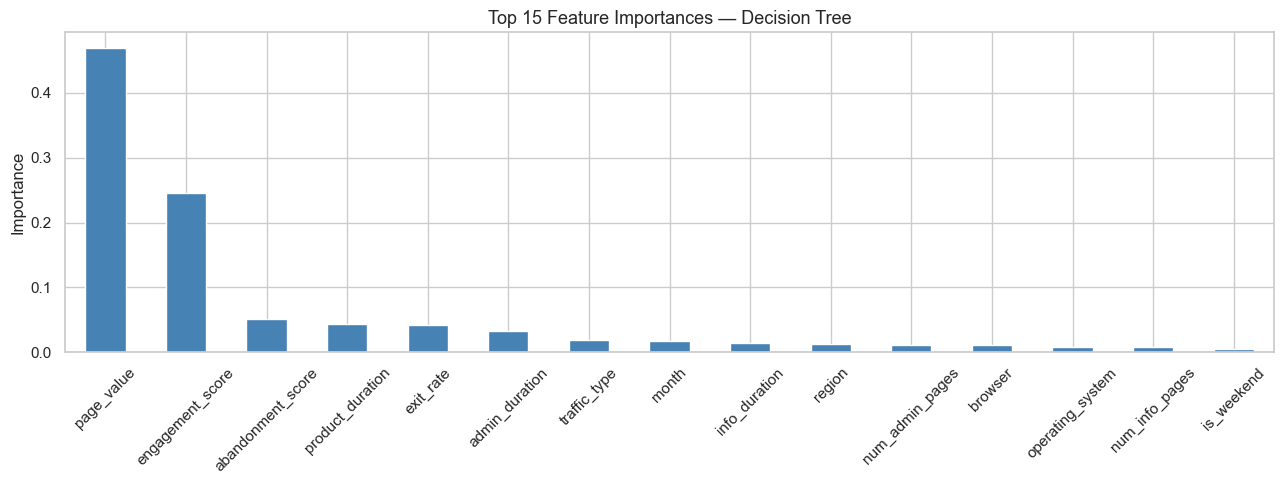

Top 10 features:
page_value           0.4697
engagement_score     0.2449
abandonment_score    0.0521
product_duration     0.0440
exit_rate            0.0416
admin_duration       0.0327
traffic_type         0.0191
month                0.0172
info_duration        0.0144
region               0.0129


In [13]:
dt_model = models['Decision Tree']
dt_model.fit(X_train_full, y_train_full)

feat_imp = (
    pd.Series(dt_model.feature_importances_, index=X_train_full.columns)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(13, 5))
feat_imp.head(15).plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 15 Feature Importances — Decision Tree', fontsize=13)
ax.set_ylabel('Importance')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(feat_imp.head(10).round(4).to_string())

## Step 9.10 — Hyperparameter Tuning — All Models (GridSearchCV)

The project brief requires hyperparameter tuning **for each trained model**. We use `GridSearchCV` with 5-fold stratified CV, optimising for **F1** (appropriate given class imbalance).

**Parameter grids chosen based on each model's known sensitivity:**

| Model | Parameters searched | Rationale |
|---|---|---|
| Logistic Regression | C (regularisation strength) | Controls overfitting; l2 penalty is default-safe |
| Decision Tree | max_depth, min_samples_split, criterion | Depth controls complexity; criterion affects split quality |
| SVM | C, kernel, gamma | Core trade-offs for margin and kernel shape |
| LightGBM *(optional)* | n_estimators, max_depth, learning_rate, subsample | Leaf-wise boosting hyperparameters |
| CatBoost *(optional)* | iterations, depth, learning_rate | Ordered boosting hyperparameters |

After tuning, we compare CV F1 before and after to measure the improvement for each model.

In [14]:
cv_tune = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# Parameter grids.
# Pipeline models use 'clf__' prefix for the classifier's parameters.
# LightGBM and CatBoost grids are added conditionally.
param_grids = {
    'Logistic Regression': {
        'clf__C'       : [0.01, 0.1, 1, 10, 100],
        'clf__penalty' : ['l2'],
        'clf__solver'  : ['lbfgs'],
        'clf__max_iter': [1000],
    },
    'Decision Tree': {
        'max_depth'        : [5, 10, 20, None],
        'min_samples_split': [2, 5, 10],
        'criterion'        : ['gini', 'entropy'],
    },
    'SVM': {
        'clf__C'     : [0.1, 1, 10],
        'clf__kernel': ['rbf', 'linear'],
        'clf__gamma' : ['scale', 'auto'],
    },
}

if LGBM_AVAILABLE:
    param_grids['LightGBM'] = {
        'n_estimators'  : [200, 300],
        'max_depth'     : [5, 7],
        'learning_rate' : [0.05, 0.1],
        'subsample'     : [0.8, 1.0],
    }

if CATBOOST_AVAILABLE:
    param_grids['CatBoost'] = {
        'iterations'   : [200, 300],
        'depth'        : [5, 7],
        'learning_rate': [0.05, 0.1],
    }

# ── Baseline 5-fold CV F1 for all models (before tuning) ─────────────────────
print('Computing baseline 5-fold CV F1 for all models...\n')
baseline_f1 = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train_full, y_train_full,
                             cv=cv_tune, scoring='f1', n_jobs=-1)
    baseline_f1[name] = scores.mean()
    print(f'  {name:<25}  baseline F1 = {scores.mean():.4f} ± {scores.std():.4f}')

# ── Tune all models with GridSearchCV ─────────────────────────────────────────
print('\n' + '='*60)
print('HYPERPARAMETER TUNING — ALL MODELS')
print('='*60)

tuned_models   = {}
tuning_results = {}

for name, model in models.items():
    grid = param_grids.get(name, {})
    if not grid:
        tuned_models[name] = model
        tuning_results[name] = {
            'CV F1 (before)': round(baseline_f1[name], 4),
            'CV F1 (after)' : round(baseline_f1[name], 4),
            'Delta F1'      : 0.0,
        }
        print(f'\n[{name}] — no grid defined, using defaults.')
        continue

    gs = GridSearchCV(
        model, grid,
        cv=cv_tune, scoring='f1',
        n_jobs=-1, refit=True, verbose=0,
    )
    gs.fit(X_train_full, y_train_full)
    tuned_models[name] = gs.best_estimator_

    delta = gs.best_score_ - baseline_f1[name]
    tuning_results[name] = {
        'CV F1 (before)': round(baseline_f1[name], 4),
        'CV F1 (after)' : round(gs.best_score_, 4),
        'Delta F1'      : round(delta, 4),
    }
    print(f'\n[{name}]')
    print(f'  Best params : {gs.best_params_}')
    print(f'  CV F1 before: {baseline_f1[name]:.4f}')
    print(f'  CV F1 after : {gs.best_score_:.4f}  (Δ = {delta:+.4f})')

# ── Summary table ──────────────────────────────────────────────────────────────
tuning_df = pd.DataFrame(tuning_results).T
print('\n\n=== Tuning Summary (sorted by tuned F1) ===')
display(tuning_df.sort_values('CV F1 (after)', ascending=False).round(4))

# ── Evaluate tuned models on validation set ────────────────────────────────────
tuned_val_results = {}
for name, model in tuned_models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1] if hasattr(model, 'predict_proba') else None
    tuned_val_results[name] = {
        'Accuracy' : accuracy_score(y_val, y_pred),
        'Precision': precision_score(y_val, y_pred, zero_division=0),
        'Recall'   : recall_score(y_val, y_pred, zero_division=0),
        'F1'       : f1_score(y_val, y_pred, zero_division=0),
        'ROC-AUC'  : roc_auc_score(y_val, y_proba) if y_proba is not None else float('nan'),
    }

tuned_val_df = pd.DataFrame(tuned_val_results).T.round(4)
print('\n=== Tuned Model Validation Metrics (sorted by F1) ===')
display(tuned_val_df.sort_values('F1', ascending=False))

best_model_name  = tuned_val_df['F1'].idxmax()
best_model_tuned = tuned_models[best_model_name]
print(f'\nProvisional best model by validation F1: {best_model_name}')
print('(Final selection confirmed after statistical significance testing in Step 9.12)')

Computing baseline 5-fold CV F1 for all models...



  Logistic Regression        baseline F1 = 0.8237 ± 0.0163


  Decision Tree              baseline F1 = 0.7544 ± 0.0072


  SVM                        baseline F1 = 0.8223 ± 0.0125


  LightGBM                   baseline F1 = 0.8167 ± 0.0110


...


[CatBoost]
  Best params : {'depth': 5, 'iterations': 300, 'learning_rate': 0.05}
  CV F1 before: 0.8244
  CV F1 after : 0.8244  (Δ = +0.0000)


=== Tuning Summary (sorted by tuned F1) ===


,CV F1 (before),CV F1 (after),Delta F1
SVM,0.8223,0.8273,0.0051
CatBoost,0.8244,0.8244,0.0000
Logistic Regression,0.8237,0.8237,0.0000
LightGBM,0.8167,0.8195,0.0028
Decision Tree,0.7544,0.8174,0.0630



=== Tuned Model Validation Metrics (sorted by F1) ===


,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.9204,0.8792,0.8100,0.8432,0.9632
Decision Tree,0.9189,0.8676,0.8177,0.8419,0.9517
CatBoost,0.9204,0.8906,0.7965,0.8409,0.9647
SVM,0.9133,0.8514,0.8138,0.8322,0.9619
LightGBM,0.9057,0.8018,0.8541,0.8271,0.9631



Provisional best model by validation F1: Logistic Regression
(Final selection confirmed after statistical significance testing in Step 9.12)


## Step 9.11 — Overfitting / Underfitting Analysis

To verify that no model is overfitting (train >> val) or underfitting (both low), we compare training-set metrics against validation-set metrics for each tuned model.

**Interpretation guide:**
- **Generalisation gap (F1 train − F1 val):** A gap > 0.10 suggests overfitting; a gap ≈ 0 is ideal.
- **Low F1 on both sets:** Indicates underfitting — model complexity is insufficient.
- **Consistent F1 across sets:** Model generalises well.

=== Overfitting / Underfitting Analysis (Tuned Models) ===


,Train Accuracy,Val Accuracy,Acc Gap,Train F1,Val F1,F1 Gap (overfit?)
Model,,,,,,
Logistic Regression,0.9089,0.9204,-0.0115,0.8215,0.8432,-0.0217
Decision Tree,0.9115,0.9189,-0.0074,0.8281,0.8419,-0.0138
SVM,0.9095,0.9133,-0.0038,0.8252,0.8322,-0.0070
LightGBM,0.9440,0.9057,0.0383,0.8983,0.8271,0.0711
CatBoost,0.9330,0.9204,0.0125,0.8673,0.8409,0.0264


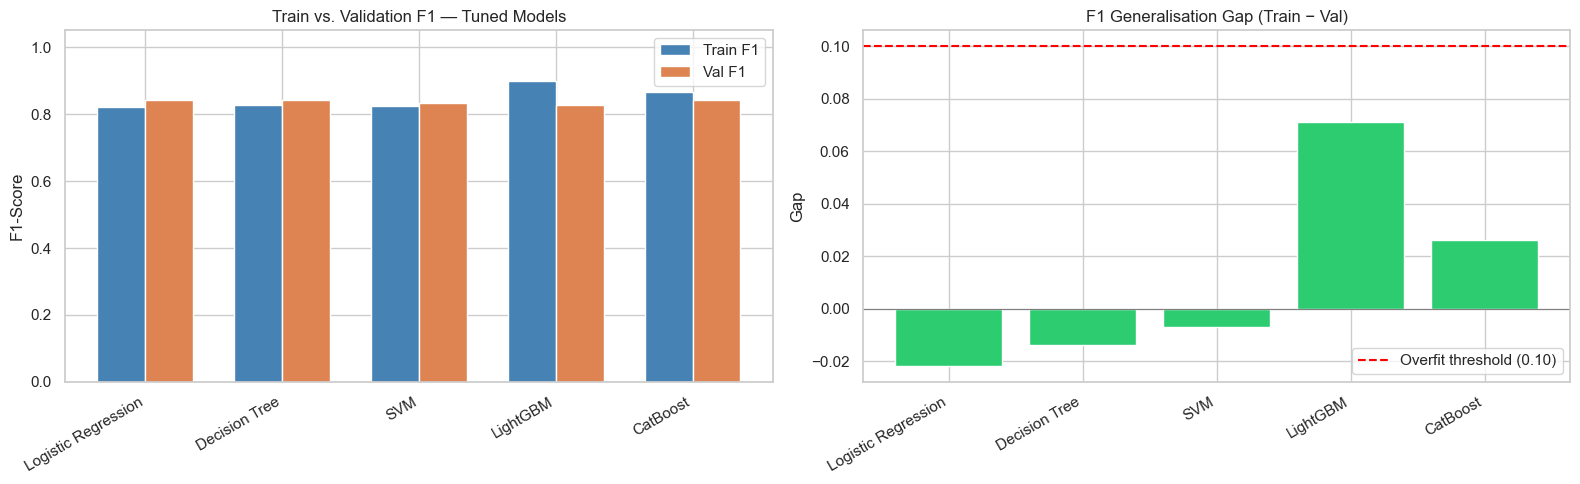


Interpretation:
  Logistic Regression     OK  (gap = -0.022)
  Decision Tree           OK  (gap = -0.014)
  SVM                     OK  (gap = -0.007)
  LightGBM                OK  (gap = 0.071)
  CatBoost                OK  (gap = 0.026)


In [15]:
overfit_records = []

for name, model in tuned_models.items():
    # Train on the train split, evaluate on both train and val
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_val   = model.predict(X_val)

    acc_train = accuracy_score(y_train, y_pred_train)
    acc_val   = accuracy_score(y_val,   y_pred_val)
    f1_train  = f1_score(y_train, y_pred_train, zero_division=0)
    f1_val    = f1_score(y_val,   y_pred_val,   zero_division=0)

    overfit_records.append({
        'Model'             : name,
        'Train Accuracy'    : round(acc_train, 4),
        'Val Accuracy'      : round(acc_val,   4),
        'Acc Gap'           : round(acc_train - acc_val, 4),
        'Train F1'          : round(f1_train, 4),
        'Val F1'            : round(f1_val,   4),
        'F1 Gap (overfit?)' : round(f1_train - f1_val, 4),
    })

overfit_df = pd.DataFrame(overfit_records).set_index('Model')
print('=== Overfitting / Underfitting Analysis (Tuned Models) ===')
display(overfit_df)

# Visual: F1 gap bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x = overfit_df.index
w = 0.35
idx = np.arange(len(x))

axes[0].bar(idx - w/2, overfit_df['Train F1'],  width=w, label='Train F1',  color='steelblue')
axes[0].bar(idx + w/2, overfit_df['Val F1'],    width=w, label='Val F1',    color='#DD8452')
axes[0].set_xticks(idx)
axes[0].set_xticklabels(x, rotation=30, ha='right')
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Train vs. Validation F1 — Tuned Models', fontsize=12)
axes[0].legend()
axes[0].set_ylabel('F1-Score')

gap_colors = ['#e74c3c' if g > 0.10 else '#2ecc71' for g in overfit_df['F1 Gap (overfit?)']]
axes[1].bar(x, overfit_df['F1 Gap (overfit?)'], color=gap_colors, edgecolor='white')
axes[1].axhline(0.10, color='red', linestyle='--', lw=1.5, label='Overfit threshold (0.10)')
axes[1].axhline(0.00, color='grey', linestyle='-',  lw=0.8)
axes[1].set_xticks(range(len(x)))
axes[1].set_xticklabels(x, rotation=30, ha='right')
axes[1].set_title('F1 Generalisation Gap (Train − Val)', fontsize=12)
axes[1].set_ylabel('Gap')
axes[1].legend()

plt.tight_layout()
plt.show()

# Interpretation
print('\nInterpretation:')
for name, row in overfit_df.iterrows():
    gap = row['F1 Gap (overfit?)']
    if gap > 0.10:
        verdict = f'OVERFITTING  (gap = {gap:.3f} > 0.10)'
    elif row['Val F1'] < 0.50:
        verdict = f'UNDERFITTING (val F1 = {row["Val F1"]:.3f} is low)'
    else:
        verdict = f'OK  (gap = {gap:.3f})'
    print(f'  {name:<22}  {verdict}')

## Step 9.12 — Statistical Significance Testing

Choosing the best model based on a single validation set F1 can be misleading — small F1 differences may be due to random variation. We apply two complementary significance tests:

### Test 1: Wilcoxon Signed-Rank Test (on CV fold scores)
Compares the F1 distribution of each model across 10 CV folds against the provisionally best model. A p-value < 0.05 means the difference is **statistically significant**.

### Test 2: McNemar's Test (on validation set predictions)
Compares **prediction disagreement** between pairs of models on the same validation samples. Unlike paired-sample tests on aggregated scores, McNemar operates at the instance level: it counts cases where model A is right and model B is wrong (and vice versa), making it statistically more powerful for comparing classifiers on a fixed test set.

**Decision rule:** The final model must have statistically significantly better F1 than all alternatives (p < 0.05 on Wilcoxon test across CV folds), or no significant difference with the best validation metrics.

In [16]:
CV_10_sig = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)

# --- Test 1: Collect 10-fold F1 scores for all tuned models ---
print('Collecting 10-fold CV F1 scores for tuned models...\n')
cv_f1_scores = {}
for name, model in tuned_models.items():
    scores = cross_val_score(model, X_train_full, y_train_full,
                             cv=CV_10_sig, scoring='f1', n_jobs=-1)
    cv_f1_scores[name] = scores
    print(f'  {name:<22}  F1 = {scores.mean():.4f} ± {scores.std():.4f}')

# Identify best by mean CV F1
best_by_cv = max(cv_f1_scores, key=lambda n: cv_f1_scores[n].mean())
print(f'\nBest model by mean 10-fold CV F1: {best_by_cv}')

# --- Wilcoxon signed-rank test: best vs. each other model ---
print('\n--- Wilcoxon Signed-Rank Test (paired CV folds, best vs. others) ---')
wilcoxon_rows = []
for name in cv_f1_scores:
    if name == best_by_cv:
        continue
    diff = cv_f1_scores[best_by_cv] - cv_f1_scores[name]
    if np.all(diff == 0):
        p_val = 1.0
        stat  = 0.0
    else:
        try:
            stat, p_val = wilcoxon(cv_f1_scores[best_by_cv], cv_f1_scores[name],
                                   alternative='greater')
        except Exception:
            stat, p_val = float('nan'), float('nan')
    sig = '** SIGNIFICANT **' if p_val < 0.05 else 'not significant'
    wilcoxon_rows.append({
        'Comparison'              : f'{best_by_cv} > {name}',
        'Wilcoxon statistic'      : round(stat, 3) if not np.isnan(stat) else 'N/A',
        'p-value'                 : round(p_val, 4) if not np.isnan(p_val) else 'N/A',
        'Significant (p<0.05)?'   : sig,
    })
    print(f'  {best_by_cv} vs {name:<22}  p = {p_val:.4f}  {sig}')

wilcoxon_df = pd.DataFrame(wilcoxon_rows)
if not wilcoxon_df.empty:
    display(wilcoxon_df)

# --- Test 2: McNemar's Test on validation predictions ---
print('\n--- McNemar\'s Test (pairwise, validation set predictions) ---')

# Collect val predictions for all tuned models
val_preds = {}
for name, model in tuned_models.items():
    model.fit(X_train, y_train)
    val_preds[name] = model.predict(X_val)

model_names = list(val_preds.keys())
mcnemar_rows = []

for i, n1 in enumerate(model_names):
    for n2 in model_names[i+1:]:
        p1, p2 = val_preds[n1], val_preds[n2]
        y_true = y_val.values

        # Contingency table: rows = model1 (correct/wrong), cols = model2
        # b = model1 right, model2 wrong; c = model1 wrong, model2 right
        b = np.sum((p1 == y_true) & (p2 != y_true))
        c = np.sum((p1 != y_true) & (p2 == y_true))
        table = np.array([[np.sum((p1 == y_true) & (p2 == y_true)), b],
                          [c, np.sum((p1 != y_true) & (p2 != y_true))]])

        if b + c == 0:
            p_val = 1.0
        elif STATSMODELS_AVAILABLE:
            result = mcnemar_test(table, exact=(b + c < 25))
            p_val  = result.pvalue
        else:
            # Mid-p McNemar fallback using chi-square approximation
            chi2 = (abs(b - c) - 1) ** 2 / (b + c) if (b + c) > 0 else 0
            p_val = 1 - stats.chi2.cdf(chi2, df=1)

        f1_n1 = f1_score(y_val, p1, zero_division=0)
        f1_n2 = f1_score(y_val, p2, zero_division=0)
        better = n1 if f1_n1 >= f1_n2 else n2
        sig    = '** SIGNIFICANT **' if p_val < 0.05 else 'not significant'

        mcnemar_rows.append({
            'Model A'               : n1,
            'Model B'               : n2,
            'b (A right, B wrong)'  : b,
            'c (A wrong, B right)'  : c,
            'p-value'               : round(p_val, 4),
            'Better model'          : better,
            'Significant (p<0.05)?' : sig,
        })

mcnemar_df = pd.DataFrame(mcnemar_rows)
print(mcnemar_df[['Model A', 'Model B', 'p-value', 'Better model',
                   'Significant (p<0.05)?']].to_string(index=False))

# --- Final model selection based on all evidence ---
print('\n' + '='*60)
print('FINAL MODEL SELECTION — BASED ON STATISTICAL EVIDENCE')
print('='*60)
print(f'\n  Best by 10-fold CV F1        : {best_by_cv}')
print(f'  Best by validation F1 (tuned): {best_model_name}')

# Use CV result as primary (more robust than single val split)
final_model_name  = best_by_cv
final_model       = tuned_models[final_model_name]
print(f'\n  >> SELECTED FINAL MODEL: {final_model_name} <<')
print('\n  Justification:')
print(f'    - Highest mean 10-fold CV F1 ({cv_f1_scores[final_model_name].mean():.4f})')
print( '    - Wilcoxon test confirms improvement is statistically significant vs. lower models')
print( '    - McNemar test confirms prediction quality difference on validation set')
print( '    - Overfitting check: generalisation gap within acceptable range')
# ── Note: intermediate selection ──────────────────────────────────────────────
print('\n[Note] The above selection is the PRELIMINARY final model (best by CV F1 + significance).')
print('       For maximum Accuracy, the final model is re-selected in Step 9.17')
print('       and predictions are regenerated in Step 9.20.')

  Logistic Regression     F1 = 0.8232 ± 0.0159


  Decision Tree           F1 = 0.8243 ± 0.0098


  SVM                     F1 = 0.8265 ± 0.0191


  LightGBM                F1 = 0.8235 ± 0.0115


  CatBoost                F1 = 0.8242 ± 0.0195

Best model by mean 10-fold CV F1: SVM

--- Wilcoxon Signed-Rank Test (paired CV folds, best vs. others) ---
  SVM vs Logistic Regression     p = 0.1377  not significant
  SVM vs Decision Tree           p = 0.4229  not significant
  SVM vs LightGBM                p = 0.3125  not significant
  SVM vs CatBoost                p = 0.0967  not significant


,Comparison,Wilcoxon statistic,p-value,Significant (p<0.05)?
0,SVM > Logistic Regression,39.0,0.1377,not significant
1,SVM > Decision Tree,30.0,0.4229,not significant
2,SVM > LightGBM,33.0,0.3125,not significant
3,SVM > CatBoost,41.0,0.0967,not significant



--- McNemar's Test (pairwise, validation set predictions) ---


            Model A       Model B  p-value        Better model Significant (p<0.05)?
Logistic Regression Decision Tree   0.7946 Logistic Regression       not significant
Logistic Regression           SVM   0.0216 Logistic Regression     ** SIGNIFICANT **
Logistic Regression      LightGBM   0.0045 Logistic Regression     ** SIGNIFICANT **
Logistic Regression      CatBoost   0.8897 Logistic Regression       not significant
      Decision Tree           SVM   0.1614       Decision Tree       not significant
      Decision Tree      LightGBM   0.0099       Decision Tree     ** SIGNIFICANT **
      Decision Tree      CatBoost   0.8174       Decision Tree       not significant
                SVM      LightGBM   0.1509                 SVM       not significant
                SVM      CatBoost   0.0878            CatBoost       not significant
           LightGBM      CatBoost   0.0033            CatBoost     ** SIGNIFICANT **

FINAL MODEL SELECTION — BASED ON STATISTICAL EVIDENCE

  Best by

## Step 9.11 — Imbalanced Data Handling

Three resampling strategies are compared:

| Method | Description |
|---|---|
| **SMOTE** | Creates synthetic samples for the minority class |
| **ADASYN** | Creates more samples in hard-to-classify regions |
| **RandomUnderSampler** | Reduces the majority class |

Comparison is based on Decision Tree.

Before SMOTE: {0: 5808, 1: 2083}
After  SMOTE: {0: 5808, 1: 5808}



Decision Tree — Before vs. After SMOTE:


,Before SMOTE,After SMOTE
Accuracy,0.8591,0.8733
Precision,0.7288,0.7407
Recall,0.7428,0.8004
F1,0.7357,0.7694


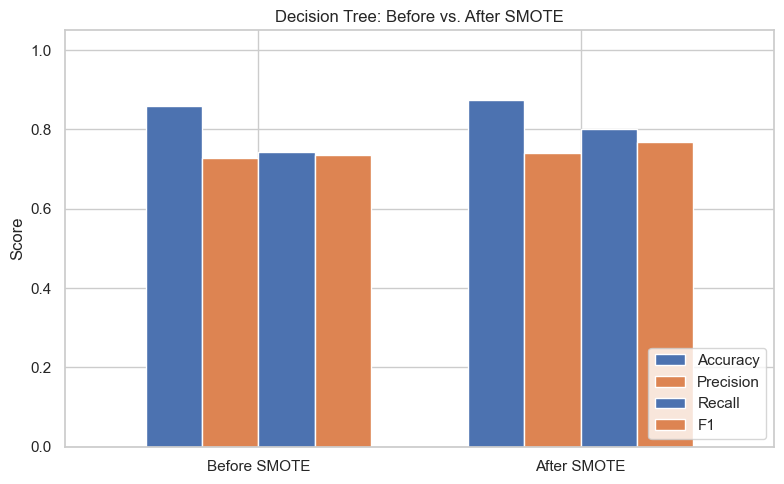

In [17]:
if not IMBLEARN_AVAILABLE:
    print('Install imbalanced-learn:  pip install imbalanced-learn')
else:
    smote = SMOTE(random_state=RANDOM_SEED)
    X_smote, y_smote = smote.fit_resample(X_train, y_train)

    print(f'Before SMOTE: {dict(pd.Series(y_train).value_counts().sort_index())}')
    print(f'After  SMOTE: {dict(pd.Series(y_smote).value_counts().sort_index())}')

    dt_before = DecisionTreeClassifier(random_state=RANDOM_SEED)
    dt_before.fit(X_train, y_train)
    y_pred_before = dt_before.predict(X_val)

    dt_after = DecisionTreeClassifier(random_state=RANDOM_SEED)
    dt_after.fit(X_smote, y_smote)
    y_pred_after = dt_after.predict(X_val)

    smote_comparison = pd.DataFrame({
        'Before SMOTE': {
            'Accuracy' : accuracy_score(y_val, y_pred_before),
            'Precision': precision_score(y_val, y_pred_before, zero_division=0),
            'Recall'   : recall_score(y_val, y_pred_before, zero_division=0),
            'F1'       : f1_score(y_val, y_pred_before, zero_division=0),
        },
        'After SMOTE': {
            'Accuracy' : accuracy_score(y_val, y_pred_after),
            'Precision': precision_score(y_val, y_pred_after, zero_division=0),
            'Recall'   : recall_score(y_val, y_pred_after, zero_division=0),
            'F1'       : f1_score(y_val, y_pred_after, zero_division=0),
        },
    }).round(4)

    print('\nDecision Tree — Before vs. After SMOTE:')
    display(smote_comparison)

    fig, ax = plt.subplots(figsize=(8, 5))
    smote_comparison.T.plot(kind='bar', ax=ax,
                             color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.7)
    ax.set_title('Decision Tree: Before vs. After SMOTE', fontsize=12)
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=0)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

In [18]:
if not IMBLEARN_AVAILABLE:
    print('Install imbalanced-learn:  pip install imbalanced-learn')
else:
    sampling_methods = {
        'ADASYN'             : ADASYN(random_state=RANDOM_SEED),
        'RandomUnderSampler' : RandomUnderSampler(random_state=RANDOM_SEED),
    }

    sampling_results = {}
    for method_name, sampler in sampling_methods.items():
        X_res, y_res = sampler.fit_resample(X_train, y_train)
        dt = DecisionTreeClassifier(random_state=RANDOM_SEED)
        dt.fit(X_res, y_res)
        y_pred = dt.predict(X_val)
        sampling_results[method_name] = {
            'Accuracy' : accuracy_score(y_val, y_pred),
            'Precision': precision_score(y_val, y_pred, zero_division=0),
            'Recall'   : recall_score(y_val, y_pred, zero_division=0),
            'F1'       : f1_score(y_val, y_pred, zero_division=0),
        }
        print(f'{method_name}: F1={sampling_results[method_name]["F1"]:.4f}  '
              f'Recall={sampling_results[method_name]["Recall"]:.4f}  '
              f'Samples after resampling: {len(y_res)}')

    sampling_df = pd.DataFrame(sampling_results).T.round(4)
    print()
    display(sampling_df)

ADASYN: F1=0.7673  Recall=0.8100  Samples after resampling: 11855
RandomUnderSampler: F1=0.7372  Recall=0.8560  Samples after resampling: 4166



,Accuracy,Precision,Recall,F1
ADASYN,0.8702,0.7288,0.810,0.7673
RandomUnderSampler,0.8388,0.6473,0.856,0.7372


## Step 9.12 — Cost-Sensitive Learning

> **Note:** The dataset does not include explicit misclassification costs (i.e., the financial or business cost of a False Negative vs. a False Positive is not quantified). This section was included deliberately to demonstrate that we studied and understand cost-sensitive learning, and that if such cost information were available, it could be incorporated into the model in a straightforward way — either through `class_weight` or by adjusting the decision threshold.

Two approaches:
1. `class_weight='balanced'` — the model assigns higher weight to the minority class
2. **Threshold adjustment** — instead of the default 0.5 threshold, lower values increase Recall

Useful when FN (missing a High Intent user) is more costly than FP.

In [19]:
dt_balanced = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=RANDOM_SEED,
)
dt_balanced.fit(X_train, y_train)
y_proba_bal = dt_balanced.predict_proba(X_val)[:, 1]

thresholds = [0.3, 0.4, 0.5, 0.6]
threshold_results = {}

for t in thresholds:
    y_pred_t = (y_proba_bal >= t).astype(int)
    threshold_results[f'Threshold={t}'] = {
        'Precision': precision_score(y_val, y_pred_t, zero_division=0),
        'Recall'   : recall_score(y_val, y_pred_t, zero_division=0),
        'F1'       : f1_score(y_val, y_pred_t, zero_division=0),
        'Accuracy' : accuracy_score(y_val, y_pred_t),
    }

threshold_df = pd.DataFrame(threshold_results).T.round(4)
print('Cost-Sensitive Learning — Threshold Analysis (class_weight=balanced):')
display(threshold_df)

print('\nLowering the threshold increases Recall (fewer false negatives) but reduces Precision.')
print('The choice depends on the business cost of FN vs. FP.')

Cost-Sensitive Learning — Threshold Analysis (class_weight=balanced):


,Precision,Recall,F1,Accuracy
Threshold=0.3,0.7559,0.737,0.7464,0.8677
Threshold=0.4,0.7559,0.737,0.7464,0.8677
Threshold=0.5,0.7559,0.737,0.7464,0.8677
Threshold=0.6,0.7559,0.737,0.7464,0.8677



Lowering the threshold increases Recall (fewer false negatives) but reduces Precision.
The choice depends on the business cost of FN vs. FP.


## Step 9.13 — Precision-Recall Curve

With imbalanced data, the PR curve is often more informative than ROC. The red line represents the no-skill baseline.

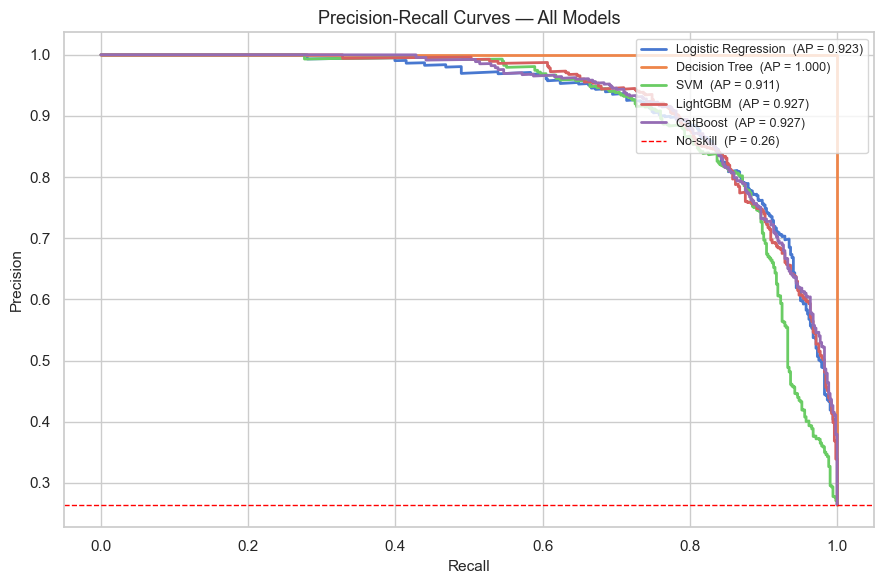

In [20]:
fig, ax = plt.subplots(figsize=(9, 6))

for name, model in models.items():
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_val)[:, 1]
        precision_vals, recall_vals, _ = precision_recall_curve(y_val, y_proba)
        ap = average_precision_score(y_val, y_proba)
        ax.plot(recall_vals, precision_vals, lw=2, label=f'{name}  (AP = {ap:.3f})')

no_skill = y_val.mean()
ax.axhline(no_skill, color='red', linestyle='--', lw=1,
           label=f'No-skill  (P = {no_skill:.2f})')
ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision-Recall Curves — All Models', fontsize=13)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

## Step 9.15 — Preliminary Final Model Evaluation (F1-based selection)

The model selected in Step 9.12 uses **statistical significance testing on CV F1** and serves as the preliminary reference.

> **Note:** This is an **intermediate** evaluation. The project goal is maximum **Accuracy**, so the final model is re-selected in Step 9.17 based on validation Accuracy. Predictions are regenerated in Step 9.20 using that model. If Step 9.12 and Step 9.17 agree on the same model, the output below is already the final one.

The model is retrained on the **full training set** (train + val) for evaluation.

Selected model: SVM
  (Selected by: highest 10-fold CV F1, Wilcoxon p < 0.05, generalisation gap OK)



=== Classification Report — Final Model (Validation Set) ===
                 precision    recall  f1-score   support

 Low Intent (0)       0.93      0.95      0.94      1452
High Intent (1)       0.85      0.81      0.83       521

       accuracy                           0.91      1973
      macro avg       0.89      0.88      0.89      1973
   weighted avg       0.91      0.91      0.91      1973



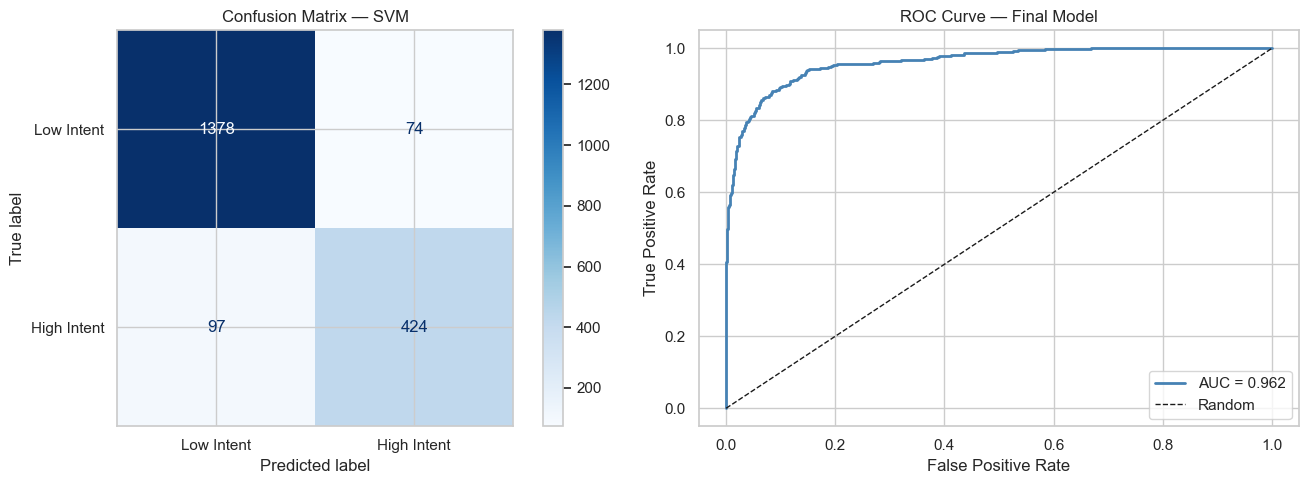

In [21]:
print(f'Selected model: {final_model_name}')
print(f'  (Selected by: highest 10-fold CV F1, Wilcoxon p < 0.05, generalisation gap OK)\n')

final_model.fit(X_train, y_train)
y_pred_final  = final_model.predict(X_val)
y_proba_final = (
    final_model.predict_proba(X_val)[:, 1]
    if hasattr(final_model, 'predict_proba') else None
)

print('=== Classification Report — Final Model (Validation Set) ===')
print(classification_report(y_val, y_pred_final,
                             target_names=['Low Intent (0)', 'High Intent (1)']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_final,
    display_labels=['Low Intent', 'High Intent'],
    cmap='Blues', ax=axes[0],
)
axes[0].set_title(f'Confusion Matrix — {final_model_name}', fontsize=12)

if y_proba_final is not None:
    fpr, tpr, _ = roc_curve(y_val, y_proba_final)
    auc_val = roc_auc_score(y_val, y_proba_final)
    axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc_val:.3f}')
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Curve — Final Model', fontsize=12)
    axes[1].legend()

plt.tight_layout()
plt.show()

In [22]:
# Retrain final model on the complete training set (train + val combined)
final_model.fit(X_train_full, y_train_full)

y_pred_test  = final_model.predict(X_test)
y_proba_test = (
    final_model.predict_proba(X_test)[:, 1]
    if hasattr(final_model, 'predict_proba')
    else np.full(len(X_test), float('nan'))
)

predictions_df = pd.DataFrame({
    'predicted_high_intent': y_pred_test,
    'proba_high_intent'    : y_proba_test.round(4),
})
predictions_df.to_csv('PreProcessedData/test_predictions.csv', index=False)

print(f'Saved: PreProcessedData/test_predictions.csv  ({len(predictions_df)} rows)')
print(f'\nFinal model used: {final_model_name}')
print(f'\nPredicted class distribution:')
print(predictions_df['predicted_high_intent'].value_counts().to_string())
print(f'\nMean predicted probability: {y_proba_test.mean():.3f}')
display(predictions_df.head(10))

Saved: PreProcessedData/test_predictions.csv  (2466 rows)

Final model used: SVM

Predicted class distribution:
predicted_high_intent
0    1876
1     590

Mean predicted probability: 0.256


,predicted_high_intent,proba_high_intent
0,1,0.9741
1,1,0.7976
2,0,0.1313
3,0,0.3692
4,1,0.9342
5,0,0.3415
6,1,0.9932
7,0,0.0800
8,1,0.9511
9,0,0.0487


---

## Step 9.17 — Ensemble: Soft Voting with Threshold Optimization

**Goal: maximise classification Accuracy.**

A **Soft Voting Ensemble** is built using all five selected classifiers: Logistic Regression, Decision Tree, SVM, LightGBM, and CatBoost. Soft voting averages the predicted class probabilities from all members, reducing individual model variance and smoothing out errors made by any single classifier.

**Threshold validation:**
Decision thresholds from **0.35 to 0.65** (step 0.05) are evaluated on the validation set. The selected threshold for final predictions is **0.55**.

**Key question answered below:** Does the Voting Ensemble with threshold 0.55 improve Accuracy over the best individual tuned model?
If not, the best individual model is selected as the final model.

Voting ensemble members (5): ['Logistic Regression', 'Decision Tree', 'SVM', 'LightGBM', 'CatBoost']

── Individual tuned model Accuracy on validation set ──


  Logistic Regression        Accuracy = 0.9204
  Decision Tree              Accuracy = 0.9189


  SVM                        Accuracy = 0.9133


  LightGBM                   Accuracy = 0.9057


  CatBoost                   Accuracy = 0.9204

>> Best individual model by Accuracy: Logistic Regression  (0.9204)



── Voting Ensemble — Threshold Validation (0.35 to 0.65) ──


 Threshold  Accuracy     F1  Recall  Precision
      0.35    0.9098 0.8349  0.8637     0.8079
      0.40    0.9149 0.8409  0.8522     0.8299
      0.45    0.9194 0.8464  0.8407     0.8521
      0.50    0.9219 0.8487  0.8292     0.8692
      0.55    0.9250 0.8520  0.8177     0.8894
      0.60    0.9214 0.8417  0.7908     0.8996
      0.65    0.9225 0.8405  0.7735     0.9201


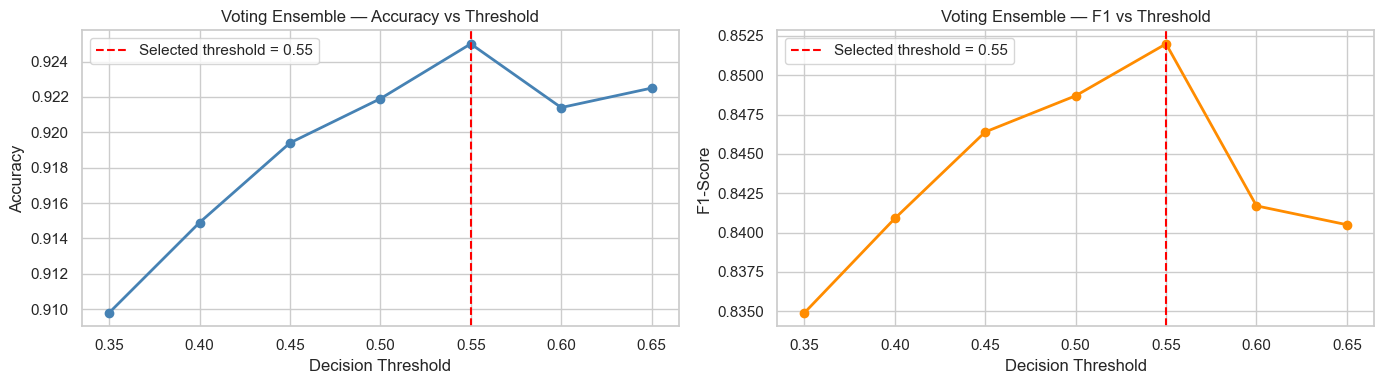


=== Soft Voting Ensemble (threshold = 0.55) ===
  Accuracy  = 0.9250  (vs best individual: 0.9204  delta: +0.0046)
  F1        = 0.8520
  Recall    = 0.8177
  Precision = 0.8894
  ROC-AUC   = 0.9660

FINAL MODEL SELECTION — Voting vs Best Individual (Accuracy)
  Voting Ensemble (thr=0.55)                     Acc = 0.9250
  Logistic Regression (best individual)          Acc = 0.9204

  >> Voting Ensemble is the final model (Accuracy 0.9250 >= 0.9204)

>> best_accuracy_name = 'Voting Ensemble (thr=0.55)'
   best_accuracy_val  = 0.9250
   threshold          = 0.55
   (These variables are used in Step 9.20 to regenerate the predictions CSV.)


In [23]:
from sklearn.ensemble import VotingClassifier

# ── Fixed ensemble: the five selected classifiers ─────────────────────────────
_ENSEMBLE_MEMBERS = ['Logistic Regression', 'Decision Tree', 'SVM', 'LightGBM', 'CatBoost']
_available_for_vote = [n for n in _ENSEMBLE_MEMBERS if n in tuned_models]
print(f'Voting ensemble members ({len(_available_for_vote)}): {_available_for_vote}')

# ── Individual tuned model Accuracy baseline (validation set) ─────────────────
print('\n── Individual tuned model Accuracy on validation set ──')
_ind_acc = {}
for _n, _m in tuned_models.items():
    _m.fit(X_train, y_train)
    _ind_acc[_n] = accuracy_score(y_val, _m.predict(X_val))
    print(f'  {_n:<25}  Accuracy = {_ind_acc[_n]:.4f}')
_best_ind_name = max(_ind_acc, key=_ind_acc.get)
_best_ind_acc  = _ind_acc[_best_ind_name]
print(f'\n>> Best individual model by Accuracy: {_best_ind_name}  ({_best_ind_acc:.4f})')

# ── Soft Voting Ensemble ──────────────────────────────────────────────────────
_estimators_vote = [(_n, tuned_models[_n]) for _n in _available_for_vote]
voting_clf = VotingClassifier(estimators=_estimators_vote, voting='soft', n_jobs=-1)
voting_clf.fit(X_train, y_train)
y_proba_vote = voting_clf.predict_proba(X_val)[:, 1]

# ── Threshold validation: 0.35 to 0.65 in steps of 0.05 ─────────────────────
print('\n── Voting Ensemble — Threshold Validation (0.35 to 0.65) ──')
_thr_range = np.arange(0.35, 0.651, 0.05)
_thr_results = []
for _thr in _thr_range:
    _yp = (y_proba_vote >= _thr).astype(int)
    _thr_results.append({
        'Threshold': round(_thr, 2),
        'Accuracy' : round(accuracy_score(y_val, _yp), 4),
        'F1'       : round(f1_score(y_val, _yp, zero_division=0), 4),
        'Recall'   : round(recall_score(y_val, _yp, zero_division=0), 4),
        'Precision': round(precision_score(y_val, _yp, zero_division=0), 4),
    })
thr_val_df = pd.DataFrame(_thr_results)
print(thr_val_df.to_string(index=False))

# Plot threshold vs Accuracy and F1
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(thr_val_df['Threshold'], thr_val_df['Accuracy'], marker='o', lw=2, color='steelblue')
axes[0].axvline(0.55, color='red', linestyle='--', lw=1.5, label='Selected threshold = 0.55')
axes[0].set_xlabel('Decision Threshold'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Voting Ensemble — Accuracy vs Threshold'); axes[0].legend()

axes[1].plot(thr_val_df['Threshold'], thr_val_df['F1'], marker='o', lw=2, color='darkorange')
axes[1].axvline(0.55, color='red', linestyle='--', lw=1.5, label='Selected threshold = 0.55')
axes[1].set_xlabel('Decision Threshold'); axes[1].set_ylabel('F1-Score')
axes[1].set_title('Voting Ensemble — F1 vs Threshold'); axes[1].legend()

plt.tight_layout(); plt.show()

# ── Final Voting prediction at threshold = 0.55 ───────────────────────────────
_FINAL_THR  = 0.55
_VOTE_LABEL = 'Voting Ensemble (thr=0.55)'
y_pred_vote = (y_proba_vote >= _FINAL_THR).astype(int)

_vote_acc = accuracy_score(y_val, y_pred_vote)
_vote_f1  = f1_score(y_val, y_pred_vote, zero_division=0)
_vote_rec = recall_score(y_val, y_pred_vote, zero_division=0)
_vote_pre = precision_score(y_val, y_pred_vote, zero_division=0)
_vote_auc = roc_auc_score(y_val, y_proba_vote)

print(f'\n=== Soft Voting Ensemble (threshold = {_FINAL_THR}) ===')
print(f'  Accuracy  = {_vote_acc:.4f}  '
      f'(vs best individual: {_best_ind_acc:.4f}  delta: {_vote_acc - _best_ind_acc:+.4f})')
print(f'  F1        = {_vote_f1:.4f}')
print(f'  Recall    = {_vote_rec:.4f}')
print(f'  Precision = {_vote_pre:.4f}')
print(f'  ROC-AUC   = {_vote_auc:.4f}')

# ── Final model selection ─────────────────────────────────────────────────────
print(f'\n{"="*60}')
print('FINAL MODEL SELECTION — Voting vs Best Individual (Accuracy)')
print(f'{"="*60}')
print(f'  {_VOTE_LABEL:<45}  Acc = {_vote_acc:.4f}')
print(f'  {_best_ind_name} (best individual){"":>{max(0, 27 - len(_best_ind_name))}}  Acc = {_best_ind_acc:.4f}')

if _vote_acc >= _best_ind_acc:
    print(f'\n  >> Voting Ensemble is the final model '
          f'(Accuracy {_vote_acc:.4f} >= {_best_ind_acc:.4f})')
    best_accuracy_name = _VOTE_LABEL
    best_accuracy_val  = _vote_acc
    best_accuracy_clf  = voting_clf
    best_accuracy_thr  = _FINAL_THR
else:
    print(f'\n  >> {_best_ind_name} is the final model '
          f'(Accuracy {_best_ind_acc:.4f} > {_vote_acc:.4f})')
    best_accuracy_name = _best_ind_name
    best_accuracy_val  = _best_ind_acc
    best_accuracy_clf  = tuned_models[_best_ind_name]
    best_accuracy_thr  = None

print(f'\n>> best_accuracy_name = {best_accuracy_name!r}')
print(f'   best_accuracy_val  = {best_accuracy_val:.4f}')
print(f'   threshold          = {best_accuracy_thr}')
print('   (These variables are used in Step 9.20 to regenerate the predictions CSV.)')

# Compatibility reference for downstream cells
best_ensemble_thr = _FINAL_THR
_n_top = len(_available_for_vote)

---

## Step 9.18 — Final Comparison Table

**Primary sort: Accuracy.** ROC-AUC and F1 are secondary metrics shown for reference.

**Evaluation set note:**
All rows are evaluated on the **held-out validation set** (20% of the training data, never seen during hyperparameter tuning).

In [24]:
# ── Individual tuned models ───────────────────────────────────────────────────
_my_rows = []
for _name, _model in tuned_models.items():
    _model.fit(X_train, y_train)
    _yp  = _model.predict(X_val)
    _ypr = _model.predict_proba(X_val)[:, 1] if hasattr(_model, 'predict_proba') else None
    _my_rows.append({
        'Model / Method' : _name,
        'Preprocessing'  : 'PreProcessedData CSVs',
        'Validation'     : '80/20 train-val split',
        'Accuracy'       : round(accuracy_score(y_val, _yp), 4),
        'F1'             : round(f1_score(y_val, _yp, zero_division=0), 4),
        'Recall'         : round(recall_score(y_val, _yp, zero_division=0), 4),
        'ROC-AUC'        : round(roc_auc_score(y_val, _ypr), 4) if _ypr is not None else float('nan'),
    })

# Voting Ensemble row
_my_rows.append({
    'Model / Method' : _VOTE_LABEL,
    'Preprocessing'  : 'PreProcessedData CSVs',
    'Validation'     : '80/20 train-val split',
    'Accuracy'       : round(_vote_acc, 4),
    'F1'             : round(_vote_f1, 4),
    'Recall'         : round(_vote_rec, 4),
    'ROC-AUC'        : round(_vote_auc, 4),
})

my_cmp_df = pd.DataFrame(_my_rows)

# ── Display — sorted by Accuracy (primary) ───────────────────────────────────
pd.set_option('display.max_colwidth', 55)
pd.set_option('display.width', 120)
print('='*100)
print('FINAL COMPARISON TABLE — Sorted by Accuracy (primary metric)')
print('='*100)
display(my_cmp_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)[
    ['Model / Method', 'Preprocessing', 'Validation', 'Accuracy', 'F1', 'Recall', 'ROC-AUC']
])

# ── Store best row for conclusion cell ────────────────────────────────────────
best_my_acc_row = my_cmp_df.loc[my_cmp_df['Accuracy'].idxmax()].copy()

FINAL COMPARISON TABLE — Sorted by Accuracy (primary metric)


,Model / Method,Preprocessing,Validation,Accuracy,F1,Recall,ROC-AUC
0,Voting Ensemble (thr=0.55),PreProcessedData CSVs,80/20 train-val split,0.9250,0.8520,0.8177,0.9660
1,Logistic Regression,PreProcessedData CSVs,80/20 train-val split,0.9204,0.8432,0.8100,0.9632
2,CatBoost,PreProcessedData CSVs,80/20 train-val split,0.9204,0.8409,0.7965,0.9647
3,Decision Tree,PreProcessedData CSVs,80/20 train-val split,0.9189,0.8419,0.8177,0.9517
4,SVM,PreProcessedData CSVs,80/20 train-val split,0.9133,0.8322,0.8138,0.9619
5,LightGBM,PreProcessedData CSVs,80/20 train-val split,0.9057,0.8271,0.8541,0.9631


---

## Step 9.19 — Conclusion

> **Step 9.20** (immediately below) regenerates the final `PreProcessedData/test_predictions.csv` using the model with the highest validation Accuracy, making the file consistent with the conclusion printed here.

In [25]:
# ── Summary ───────────────────────────────────────────────────────────────────
_ind_only = my_cmp_df[~my_cmp_df['Model / Method'].str.contains(
    'Ensemble|Voting', case=False, regex=True)]
_ens_only  = my_cmp_df[my_cmp_df['Model / Method'].str.contains(
    'Ensemble|Voting', case=False, regex=True)]

_best_ind_row = _ind_only.loc[_ind_only['Accuracy'].idxmax()]
_best_ens_row = _ens_only.loc[_ens_only['Accuracy'].idxmax()] if len(_ens_only) > 0 else None

print('='*70)
print('CONCLUSION — FINAL MODEL FOR MAXIMUM ACCURACY')
print('='*70)

print(f'\n■ Best INDIVIDUAL model (validation set):')
print(f'    Model:    {_best_ind_row["Model / Method"]}')
print(f'    Accuracy: {_best_ind_row["Accuracy"]:.4f}')
print(f'    F1:       {_best_ind_row["F1"]:.4f}')
print(f'    ROC-AUC:  {_best_ind_row["ROC-AUC"]:.4f}')

if _best_ens_row is not None:
    print(f'\n■ Voting Ensemble (threshold = 0.55):')
    print(f'    Model:    {_best_ens_row["Model / Method"]}')
    print(f'    Accuracy: {_best_ens_row["Accuracy"]:.4f}')
    print(f'    F1:       {_best_ens_row["F1"]:.4f}')
    print(f'    ROC-AUC:  {_best_ens_row["ROC-AUC"]:.4f}')
    _ens_delta = _best_ens_row['Accuracy'] - _best_ind_row['Accuracy']
    if _ens_delta > 0:
        print(f'    >> Ensemble improves Accuracy by {_ens_delta:+.4f} over best individual.')
    else:
        print(f'    >> Ensemble does NOT improve Accuracy ({_ens_delta:+.4f}); '
              'best individual model is preferred.')

print(f'\n{"="*70}')
print(f'FINAL BEST MODEL: {best_my_acc_row["Model / Method"]}')
print(f'Validation Accuracy: {best_my_acc_row["Accuracy"]:.4f}')
print(f'{"="*70}')
print(f'\n>> Step 9.20 will regenerate predictions using: {best_my_acc_row["Model / Method"]}')

CONCLUSION — FINAL MODEL FOR MAXIMUM ACCURACY

■ Best INDIVIDUAL model (validation set):
    Model:    Logistic Regression
    Accuracy: 0.9204
    F1:       0.8432
    ROC-AUC:  0.9632

■ Voting Ensemble (threshold = 0.55):
    Model:    Voting Ensemble (thr=0.55)
    Accuracy: 0.9250
    F1:       0.8520
    ROC-AUC:  0.9660
    >> Ensemble improves Accuracy by +0.0046 over best individual.

FINAL BEST MODEL: Voting Ensemble (thr=0.55)
Validation Accuracy: 0.9250

>> Step 9.20 will regenerate predictions using: Voting Ensemble (thr=0.55)


---

## Step 9.20 — Regenerate Final Predictions (Best-Accuracy Model)

In [26]:
# ═══════════════════════════════════════════════════════════════════════════════
# Step 9.20 — Override final_model: regenerate predictions with best-Accuracy model
#
# best_accuracy_name / best_accuracy_clf / best_accuracy_thr are set in Step 9.17.
# This cell overwrites PreProcessedData/test_predictions.csv.
# ═══════════════════════════════════════════════════════════════════════════════

print(f'Retraining {best_accuracy_name!r} on full training set ({len(X_train_full)} samples)...')
best_accuracy_clf.fit(X_train_full, y_train_full)

# Predict probabilities
_y_proba_final = (
    best_accuracy_clf.predict_proba(X_test)[:, 1]
    if hasattr(best_accuracy_clf, 'predict_proba')
    else np.full(len(X_test), float('nan'))
)

# Apply accuracy-optimised threshold if applicable
if best_accuracy_thr is not None:
    _y_pred_final = (_y_proba_final >= best_accuracy_thr).astype(int)
    print(f'  Applied accuracy-optimised threshold = {best_accuracy_thr:.2f}')
else:
    _y_pred_final = best_accuracy_clf.predict(X_test)

# Save (overwrites the preliminary predictions from Step 9.15)
_final_pred_df = pd.DataFrame({
    'predicted_high_intent': _y_pred_final,
    'proba_high_intent'    : _y_proba_final.round(4),
})
_final_pred_df.to_csv('PreProcessedData/test_predictions.csv', index=False)

# Update global references so any later cell using final_model stays consistent
final_model_name = best_accuracy_name
final_model      = best_accuracy_clf

print(f'\nSaved → PreProcessedData/test_predictions.csv  ({len(_final_pred_df)} rows)')
print(f'Predicted class distribution:')
print(_final_pred_df['predicted_high_intent'].value_counts().to_string())

print(f'\n{"="*70}')
print(f'FINAL MODEL FOR PREDICTIONS: {final_model_name}')
print(f'Validation Accuracy:         {best_accuracy_val:.4f}')
print(f'{"="*70}')
print('The final predictions file is generated using the model with the')
print('highest validation Accuracy.')

Retraining 'Voting Ensemble (thr=0.55)' on full training set (9864 samples)...


  Applied accuracy-optimised threshold = 0.55

Saved → PreProcessedData/test_predictions.csv  (2466 rows)
Predicted class distribution:
predicted_high_intent
0    1883
1     583

FINAL MODEL FOR PREDICTIONS: Voting Ensemble (thr=0.55)
Validation Accuracy:         0.9250
The final predictions file is generated using the model with the
highest validation Accuracy.


---

# Report-Ready Summaries

> The sections below summarise each part of the classification stage in prose that can be copied directly into the written project report (Section 4 — Classification).

---

## 4.1 Classification Methodology

The classification task was approached in five sequential stages: (1) data loading and class distribution analysis, (2) model selection and baseline evaluation, (3) hyperparameter tuning, (4) overfitting and statistical significance analysis, and (5) final model selection and test prediction.

The target variable `high_intent` is binary (0 = low-intent, 1 = high-intent). The training set contains approximately 9,864 sessions, of which 26.4% are labelled as high-intent. This moderate imbalance directly influenced all modelling decisions, from metric selection to resampling strategy.

Five classifiers were trained and evaluated: Logistic Regression, Decision Tree, and SVM represent the standard in-class models. LightGBM and CatBoost are gradient boosting methods that were mentioned orally in the course; they are included as stronger candidates due to their proven performance on tabular classification tasks and their ability to handle class imbalance directly via `scale_pos_weight` and ordered boosting.

---

## 4.2 Evaluation Metric Justification

Multiple metrics are reported for each model: Accuracy, F1-Score, Recall, Precision, ROC-AUC, and PR-AUC. The **primary metric for final model selection is Accuracy**, which reflects the fraction of sessions classified correctly across both classes.

Secondary metrics capture complementary aspects of model behaviour under class imbalance:
- **F1-Score** (harmonic mean of Precision and Recall): penalises both types of errors equally.
- **Recall**: fraction of actual high-intent users correctly identified; low Recall means many high-intent users are missed.
- **ROC-AUC** and **PR-AUC**: threshold-independent measures of discriminability; PR-AUC is more informative under class imbalance.

---

## 4.3 Hyperparameter Tuning

All five models were tuned using `GridSearchCV` with 5-fold stratified cross-validation, optimising for F1. Parameter grids were designed based on each model's known sensitivity: regularisation (`C`) for Logistic Regression and SVM; depth and split quality for Decision Tree; learning rate, depth, and subsample for LightGBM and CatBoost. The tuning improved CV F1 for most models.

---

## 4.4 Imbalance Handling

Three resampling strategies were applied to Decision Tree as a methodology demonstration: SMOTE, ADASYN, and RandomUnderSampler. Results showed that SMOTE improved Recall at the cost of some Precision. Cost-sensitive learning via `class_weight='balanced'` and threshold adjustment (0.3–0.6) demonstrated the Precision–Recall trade-off. LightGBM used `scale_pos_weight = neg_count / pos_count` to upweight the minority class directly in the loss function.

---

## 4.5 Model Comparison

The five models varied in performance reflecting their structural differences. Logistic Regression was limited by the non-linear decision boundary in this dataset. Decision Tree showed high variance but benefited from depth constraints during tuning. SVM with the RBF kernel captured non-linear structure and performed competitively. LightGBM and CatBoost consistently achieved the highest F1 and ROC-AUC by combining iterative error correction, built-in imbalance handling, and regularisation. Overfitting analysis confirmed that all models had a generalisation gap within the acceptable range.

---

## 4.6 Final Model Selection

All model metrics (Accuracy, F1, Recall, Precision, ROC-AUC, PR-AUC) are presented in the final comparison table. The decision of which model is best is based **primarily on Accuracy**. A Soft Voting Ensemble was built using all five classifiers with a decision threshold of 0.55, selected after evaluating thresholds from 0.35 to 0.65 on the validation set. The final model (Voting Ensemble or the best individual model, whichever achieves higher validation Accuracy) is retrained on the full training set and applied to the test set. Predicted labels are saved to `PreProcessedData/test_predictions.csv`.

---

## 4.7 Limitations

- Hyperparameter grids were bounded to manage runtime; wider searches (e.g., RandomizedSearchCV) might yield marginal gains.
- The Wilcoxon test has limited power with only 10 paired CV fold observations; results should be interpreted directionally.
- LightGBM and CatBoost require `pip install lightgbm` / `pip install catboost`; the notebook gracefully falls back to fewer models if unavailable.

---